<a href="https://colab.research.google.com/github/aniruddhagalgali/bprim_ai/blob/main/20260830_NSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
#For Stationarity test (Adam Fuller Test)
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [35]:
#Import NIFTY data
data = yf.download("^NSEI", start = "2021-01-01", end = "2026-01-01", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


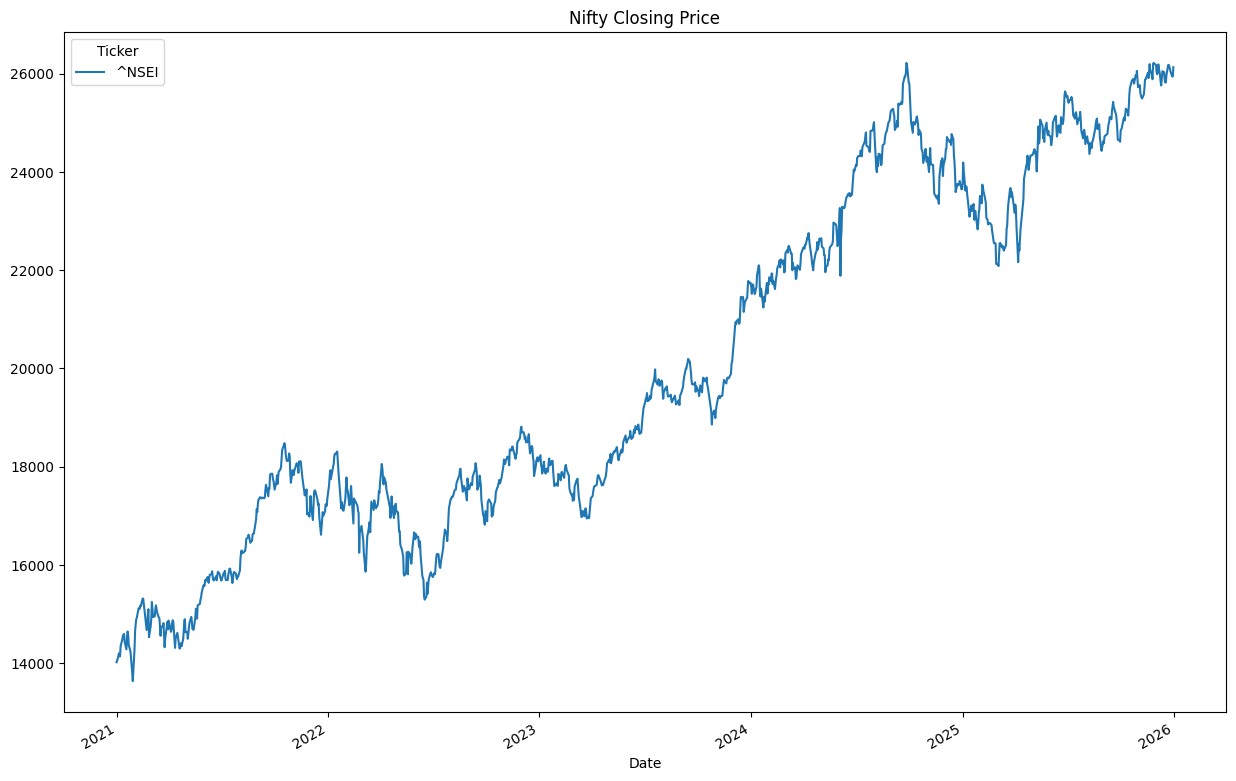

In [36]:
close = data['Close'].dropna()
close.plot(figsize=(15,10),title="Nifty Closing Price")
plt.show()

In [37]:
print("Min Price:", round(close.min().iloc[0],2), "on", close.idxmin().iloc[0].strftime('%Y-%m-%d'))
print("Max Price:", round(close.max().iloc[0],2), "on", close.idxmax().iloc[0].strftime('%Y-%m-%d'))
print("Mean Price:", round(close.mean().iloc[0],2))
print("Standard Deviation: ", round(close.std().iloc[0],2))

Min Price: 13634.6 on 2021-01-29
Max Price: 26216.05 on 2024-09-26
Mean Price: 20049.31
Standard Deviation:  3587.26


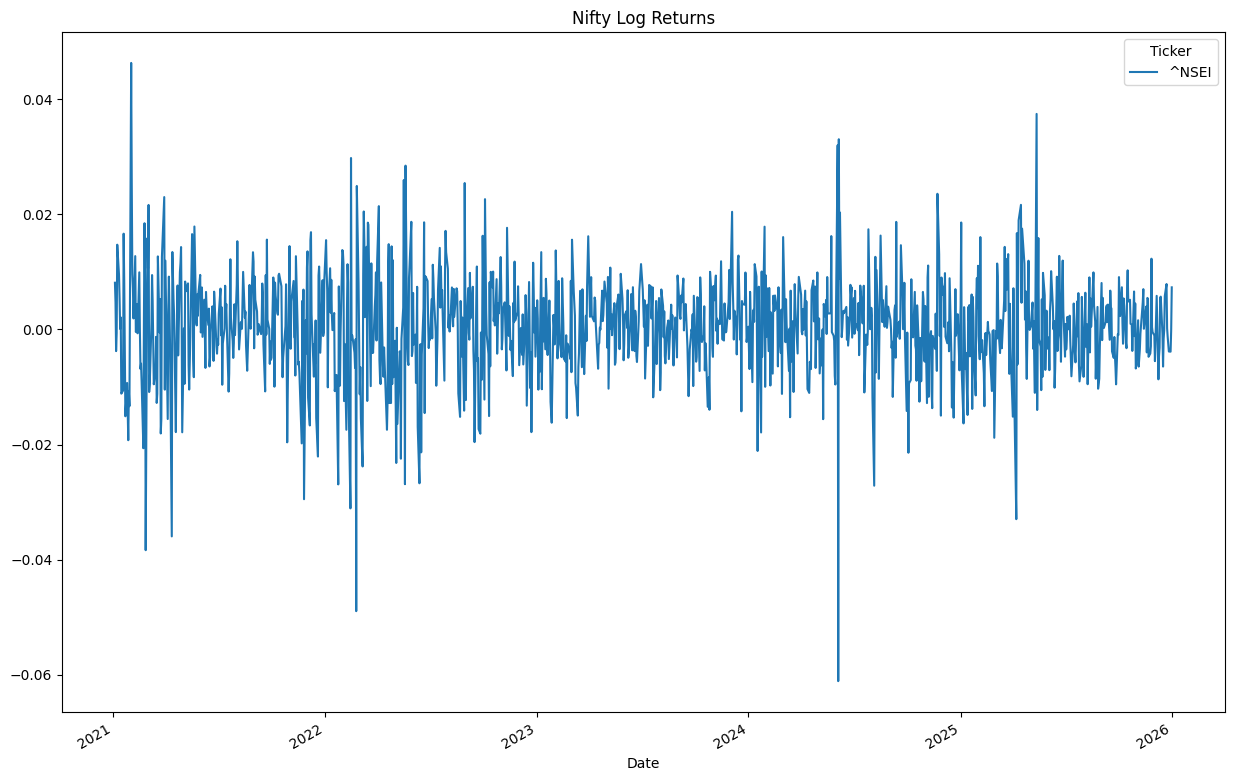

In [38]:
#Log returns
#Shift 1 means prior day's value. If you use 2, it'll use the values of 2 day's prior
log_return = np.log(close/close.shift(1)).dropna()
log_return.plot(figsize=(15,10),title="Nifty Log Returns")
plt.show()

In [39]:
#Summary of log_returns
print((log_return*100).describe().round(2))

Ticker    ^NSEI
count   1235.00
mean       0.05
std        0.88
min       -6.11
25%       -0.41
50%        0.06
75%        0.56
max        4.63


In [40]:
#Since returns are log_returns we can simply extrapolate daily to yearly
trading_days = 252
annual_returns = log_return.mean()*trading_days
annual_volatility = log_return.std()*np.sqrt(trading_days)
print("Annual Returns:", round(annual_returns*100,2))
print("Annual Volatility:", round(annual_volatility*100,2))
annual_sharpe = annual_returns/annual_volatility
print("Annual Sharpe Ratio:", round(annual_sharpe,2))

Annual Returns: Ticker
^NSEI    12.71
dtype: float64
Annual Volatility: Ticker
^NSEI    14.01
dtype: float64
Annual Sharpe Ratio: Ticker
^NSEI    0.91
dtype: float64


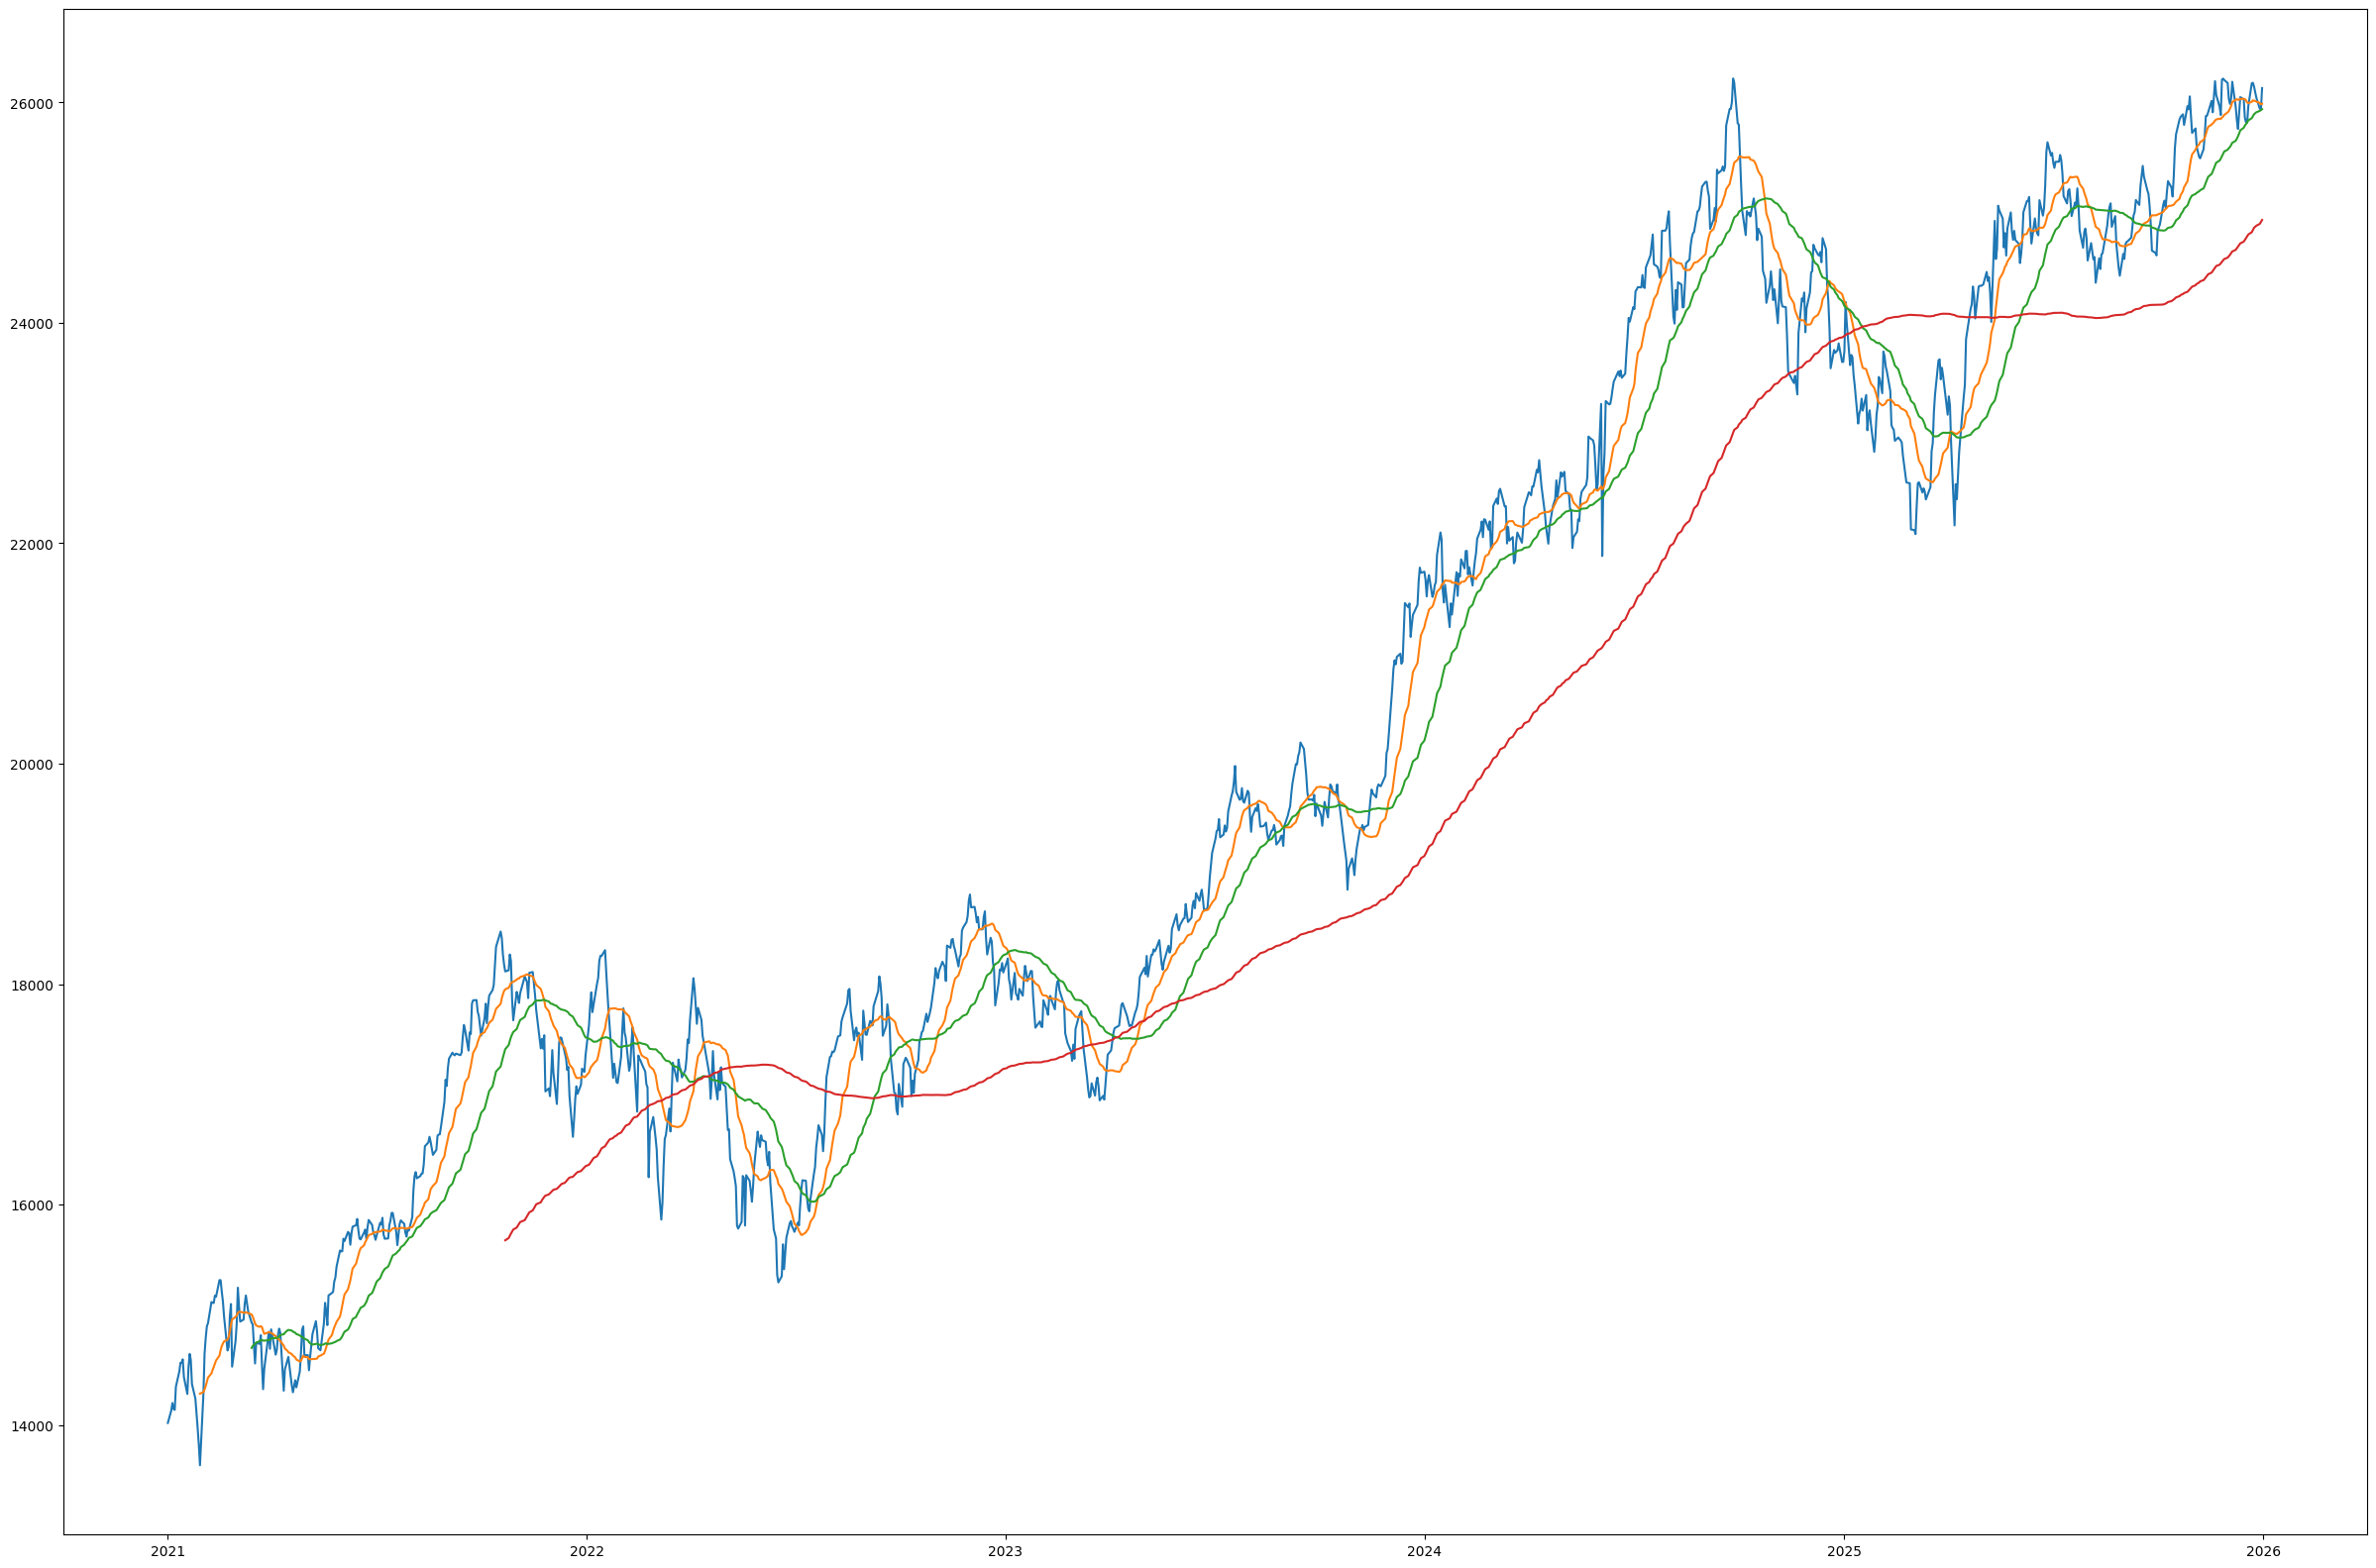

In [41]:
#Calculate moving averages
ma20 = close.rolling(window=20).mean()
ma50 = close.rolling(window=50).mean()
ma200 = close.rolling(window=200).mean()
#Plot
plt.figure(figsize=(30,20))
plt.plot(close, label="Close Price")
plt.plot(ma20, label="20 Day MA")
plt.plot(ma50, label="50 Day MA")
plt.plot(ma200, label="200 Day MA")

In [42]:
#Stationarity test (Adam Fuller Test)
price_p = adfuller(close)
print("Price ADF Statistic:", price_p)

Price ADF Statistic: (np.float64(-0.8229039621179185), np.float64(0.8123014540822637), 0, 1235, {'1%': np.float64(-3.4356560275160835), '5%': np.float64(-2.8638831211270817), '10%': np.float64(-2.568017509711682)}, np.float64(15892.094324435755))


In [43]:
#Stationarity test (Adam Fuller Test)
#p-value should be less than 0.05 for data to be stationary
price_p = adfuller(close)
print("Price ADF Statistic:", round(price_p[0], 4))
print("Price P-value:", round(price_p[1], 4))
if price_p[1] < 0.05:
    print("The Price series is stationary (p-value < 0.05)")
else:
    print("The Price series is not stationary (p-value >= 0.05)")
print("Price Critical Values:")


returns_p = adfuller(log_return)
print("\nLog Returns ADF Statistic:", round(returns_p[0], 4))
print("Log Returns P-value:", round(returns_p[1], 4))
if returns_p[1] < 0.05:
    print("The Log Returns series is stationary (p-value < 0.05)")
else:
    print("The Log Returns series is not stationary (p-value >= 0.05)")
print("Log Returns Critical Values:")

Price ADF Statistic: -0.8229
Price P-value: 0.8123
The Price series is not stationary (p-value >= 0.05)
Price Critical Values:

Log Returns ADF Statistic: -34.7103
Log Returns P-value: 0.0
The Log Returns series is stationary (p-value < 0.05)
Log Returns Critical Values:


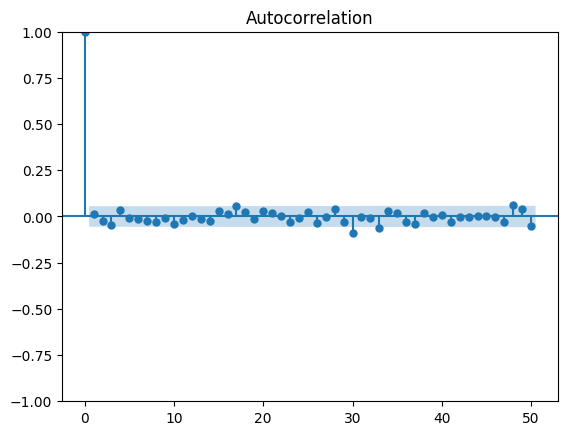

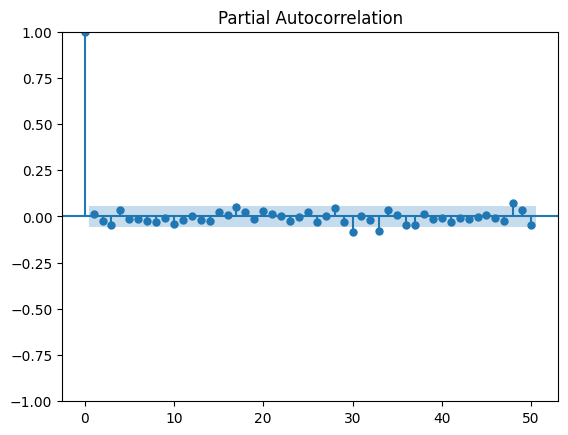

In [45]:
#Auto corelation function
plot_acf(log_return, lags=50)
plt.show()
plot_pacf(log_return, lags=50)
plt.show()